# Precision Agriculture: Explainable Crop Recommendation System using Machine Learning and Explainable AI (SHAP & LIME)

This notebook implements a complete machine learning pipeline for **precision agriculture crop recommendation**. It integrates:
1. **Exploratory Data Analysis (EDA)**
2. **Data Preprocessing & Target Encoding**
3. **Multi-Model Comparison** involving 11 classifiers (Traditional ML vs. Advanced Boosting Ensembles like XGBoost, LightGBM, CatBoost)
4. **Performance Evaluation** (Accuracy, Precision, Recall, F1-Score, Confusion Matrix, ROC-AUC Curves)
5. **Explainable AI (XAI)** frameworks: **SHAP** (global & local feature importance) and **LIME** (instance-level local explanations)
6. **Top-3 Recommender System** with confidence levels for risk-managed agricultural advice.

## 1. Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import warnings
warnings.filterwarnings('ignore')

# Modeling & Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, auc

# Classifiers
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, ExtraTreeClassifier
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier, AdaBoostClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

# Explainable AI
import shap
from lime import lime_tabular

## 2. Load Dataset

In [2]:
# Load the agricultural dataset
crop = pd.read_csv("data 2/Crop Recommendation dataset.csv")
print(f"Dataset Shape: {crop.shape}")
print(f"Missing Values: {crop.isnull().sum().sum()}")
print(f"Duplicate Rows: {crop.duplicated().sum()}")
crop.head()

Dataset Shape: (2200, 8)
Missing Values: 0
Duplicate Rows: 0


,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


## 2.1 Exploratory Data Analysis (EDA): Feature Correlation Heatmap

We plot a correlation heatmap of the numerical features (Nitrogen, Phosphorus, Potassium, Temperature, Humidity, pH, and Rainfall) to understand feature interactions and check for multicollinearity.

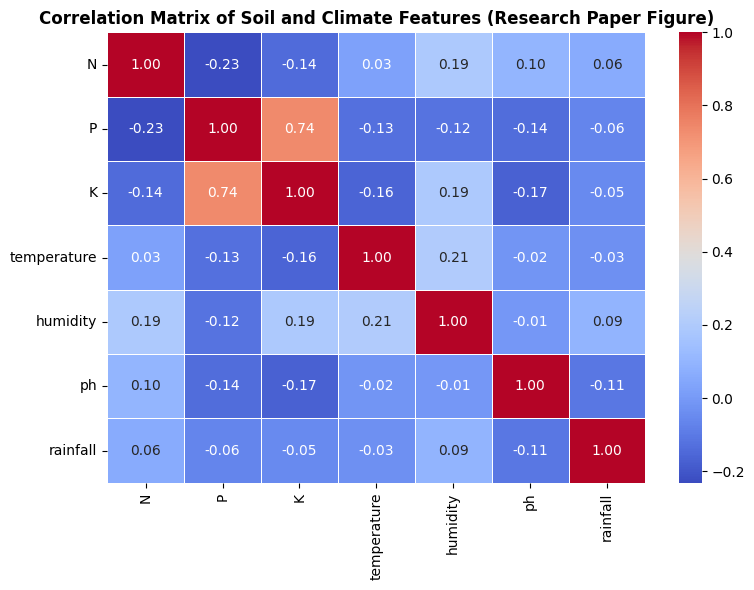

In [3]:
# Calculate correlation matrix for features
plt.figure(figsize=(8, 6))
feature_cols = ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']
corr_matrix = crop[feature_cols].corr()

# Plot Heatmap
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix of Soil and Climate Features (Research Paper Figure)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('combined_correlation_heatmap.png', dpi=300)
plt.show()

## 3. Data Preprocessing & Target Encoding

To ensure compatibility with all classifiers (especially XGBoost and LightGBM which require 0-indexed targets), we map the crop names to integers from `0` to `21`.

In [4]:
crop_dict = {
    'rice': 1, 'maize': 2, 'jute': 3, 'cotton': 4, 'coconut': 5,
    'papaya': 6, 'orange': 7, 'apple': 8, 'muskmelon': 9, 'watermelon': 10,
    'grapes': 11, 'mango': 12, 'banana': 13, 'pomegranate': 14, 'lentil': 15,
    'blackgram': 16, 'mungbean': 17, 'mothbeans': 18, 'pigeonpeas': 19,
    'kidneybeans': 20, 'chickpea': 21, 'coffee': 22
}

# Map target labels to 0-indexed integers (0 to 21)
crop['crop_num'] = crop['label'].map(crop_dict) - 1
crop_names_dict = {v - 1: k.capitalize() for k, v in crop_dict.items()}

# Drop raw label and inspect target distribution
crop.drop(['label'], axis=1, inplace=True)
print(crop['crop_num'].value_counts())
crop.head()

crop_num
0     100
1     100
2     100
3     100
4     100
5     100
6     100
7     100
8     100
9     100
10    100
11    100
12    100
13    100
14    100
15    100
16    100
17    100
18    100
19    100
20    100
21    100
Name: count, dtype: int64


,N,P,K,temperature,humidity,ph,rainfall,crop_num
0,90,42,43,20.879744,82.002744,6.502985,202.935536,0
1,85,58,41,21.770462,80.319644,7.038096,226.655537,0
2,60,55,44,23.004459,82.320763,7.840207,263.964248,0
3,74,35,40,26.491096,80.158363,6.980401,242.864034,0
4,78,42,42,20.130175,81.604873,7.628473,262.717340,0


## 4. Stratified Train-Test Split & Feature Scaling

We use a stratified split to maintain exactly 20% validation samples for each crop type, ensuring robust evaluation. All soil/weather variables are scaled to a `[0, 1]` range using a `MinMaxScaler`.

In [5]:
X = crop.drop(['crop_num'], axis=1)
y = crop['crop_num']

# Stratified split for class balance representation
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Feature scaling using MinMaxScaler
ms = MinMaxScaler()
X_train = ms.fit_transform(X_train)
X_test = ms.transform(X_test)

print(f"Training set shape: {X_train.shape}")
print(f"Testing set shape: {X_test.shape}")

Training set shape: (1760, 7)
Testing set shape: (440, 7)


## 5. Model Definition and Training

We define a comprehensive suite of machine learning classifiers to run a structured comparison.

In [6]:
models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=500),
    'Support Vector Machine': SVC(probability=True, random_state=42),
    'Naive Bayes': GaussianNB(),
    'K-Nearest Neighbors': KNeighborsClassifier(),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Extra Trees': ExtraTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'Bagging': BaggingClassifier(random_state=42),
    'AdaBoost': AdaBoostClassifier(random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    'XGBoost': XGBClassifier(random_state=42, eval_metric='mlogloss'),
    'LightGBM': LGBMClassifier(random_state=42, verbose=-1),
    'CatBoost': CatBoostClassifier(random_state=42, verbose=0)
}

results = []

for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train, y_train)
    ypred = model.predict(X_test)
    
    acc = accuracy_score(y_test, ypred)
    prec = precision_score(y_test, ypred, average='weighted')
    rec = recall_score(y_test, ypred, average='weighted')
    f1 = f1_score(y_test, ypred, average='weighted')
    
    results.append({
        'Model': name,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1-Score': f1
    })
    print(f"{name} - Accuracy: {acc:.4f} | F1-Score: {f1:.4f}")

results_df = pd.DataFrame(results)
print("\n--- Combined Model Evaluation Results ---")
results_df

Training Logistic Regression...
Logistic Regression - Accuracy: 0.9364 | F1-Score: 0.9355
Training Support Vector Machine...


Support Vector Machine - Accuracy: 0.9795 | F1-Score: 0.9794
Training Naive Bayes...
Naive Bayes - Accuracy: 0.9955 | F1-Score: 0.9955
Training K-Nearest Neighbors...
K-Nearest Neighbors - Accuracy: 0.9795 | F1-Score: 0.9795
Training Decision Tree...
Decision Tree - Accuracy: 0.9818 | F1-Score: 0.9817
Training Extra Trees...
Extra Trees - Accuracy: 0.8932 | F1-Score: 0.8925
Training Random Forest...


Random Forest - Accuracy: 0.9977 | F1-Score: 0.9977
Training Bagging...
Bagging - Accuracy: 0.9841 | F1-Score: 0.9840
Training AdaBoost...
AdaBoost - Accuracy: 0.3091 | F1-Score: 0.1840
Training Gradient Boosting...


Gradient Boosting - Accuracy: 0.9909 | F1-Score: 0.9909
Training XGBoost...


XGBoost - Accuracy: 0.9886 | F1-Score: 0.9886
Training LightGBM...


LightGBM - Accuracy: 0.9886 | F1-Score: 0.9887
Training CatBoost...


CatBoost - Accuracy: 0.9932 | F1-Score: 0.9932

--- Combined Model Evaluation Results ---


,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.936364,0.942051,0.936364,0.935490
1,Support Vector Machine,0.979545,0.982340,0.979545,0.979352
2,Naive Bayes,0.995455,0.995455,0.995455,0.995455
3,K-Nearest Neighbors,0.979545,0.981281,0.979545,0.979485
4,Decision Tree,0.981818,0.983124,0.981818,0.981741
5,Extra Trees,0.893182,0.898079,0.893182,0.892465
6,Random Forest,0.997727,0.997835,0.997727,0.997726
7,Bagging,0.984091,0.985092,0.984091,0.984024
8,AdaBoost,0.309091,0.143326,0.309091,0.184038
9,Gradient Boosting,0.990909,0.991736,0.990909,0.990948


## 6. Model Performance Comparison Visualization

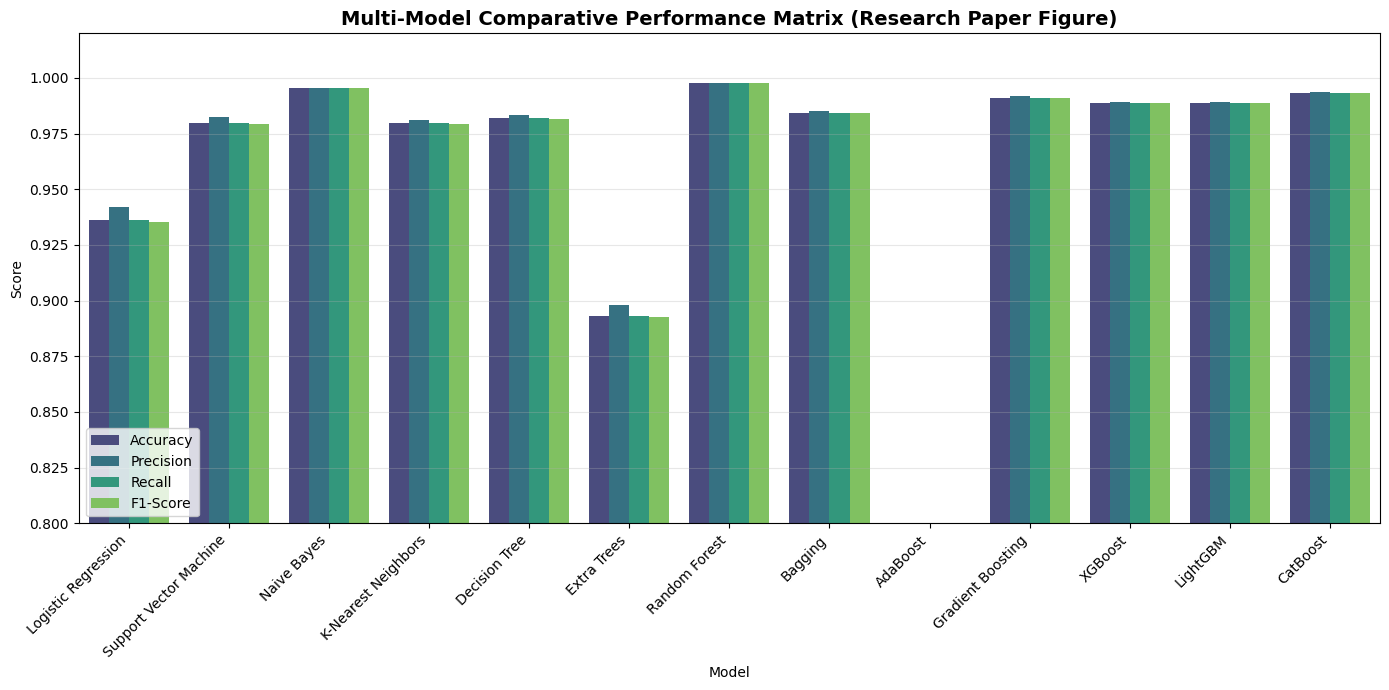

In [7]:
plt.figure(figsize=(14, 7))
melted_df = pd.melt(results_df, id_vars="Model", var_name="Metric", value_name="Value")
sns.barplot(x="Model", y="Value", hue="Metric", data=melted_df, palette="viridis")
plt.title("Multi-Model Comparative Performance Matrix (Research Paper Figure)", fontsize=14, fontweight='bold')
plt.ylim(0.8, 1.02)
plt.ylabel("Score")
plt.xticks(rotation=45, ha='right')
plt.legend(loc='lower left')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig("combined_model_comparison.png", dpi=300)
plt.show()

## 7. Select and Evaluate Best Performing Model

We dynamically select the classifier with the highest F1-Score to plot its Confusion Matrix and ROC-AUC curves.

Best Model Selected: Random Forest


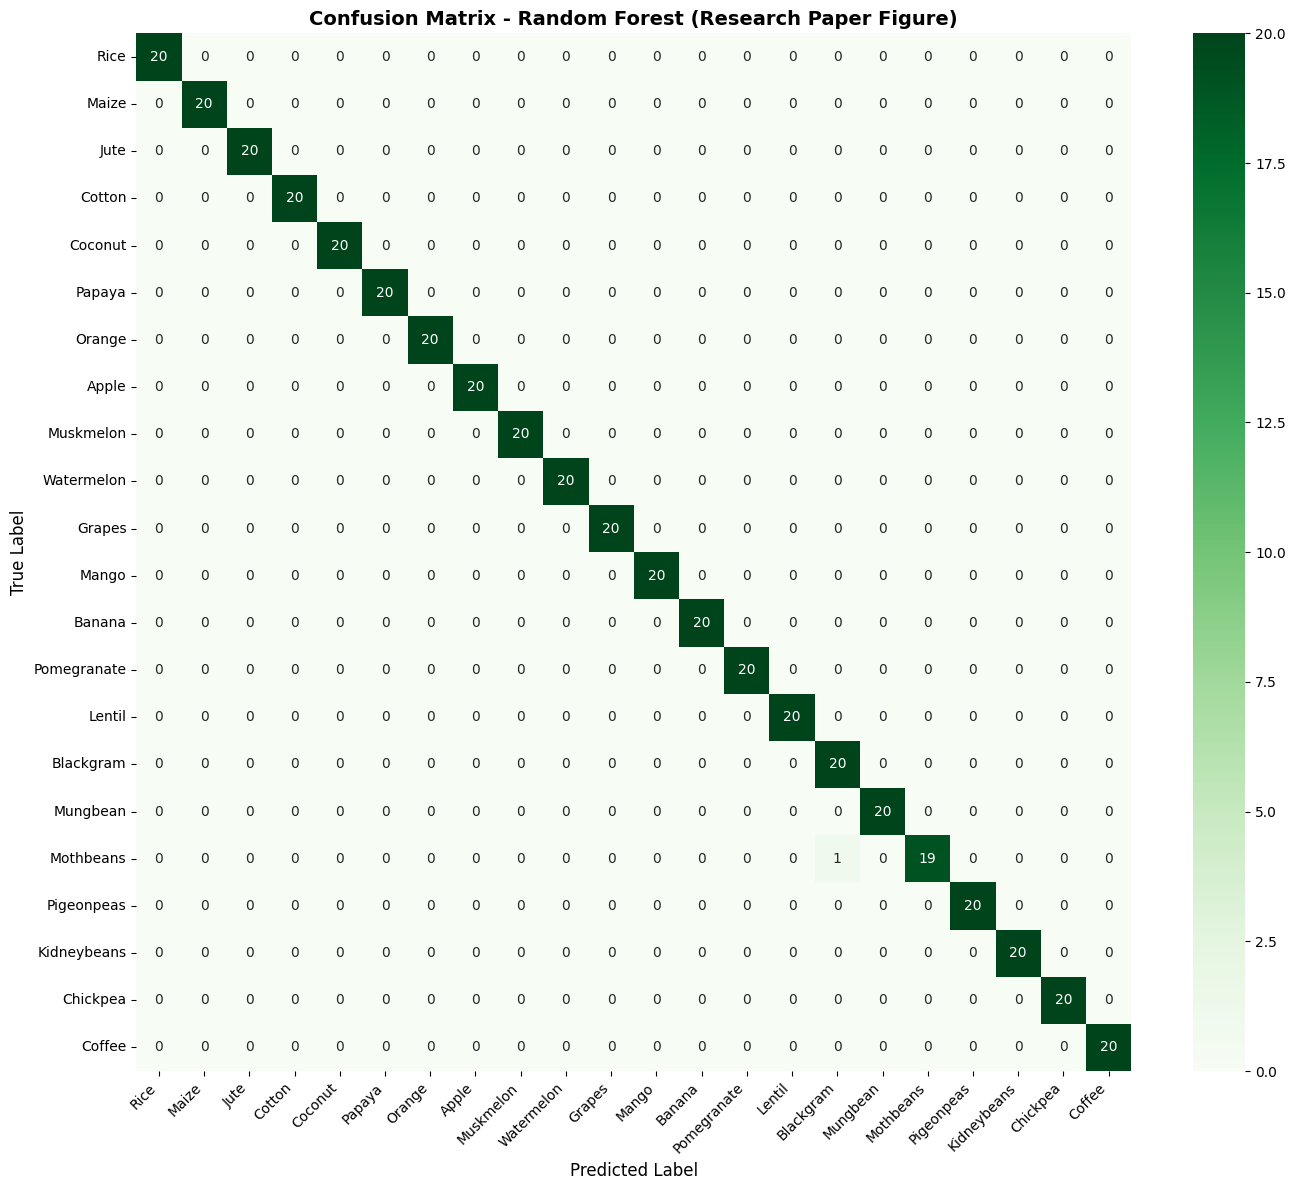

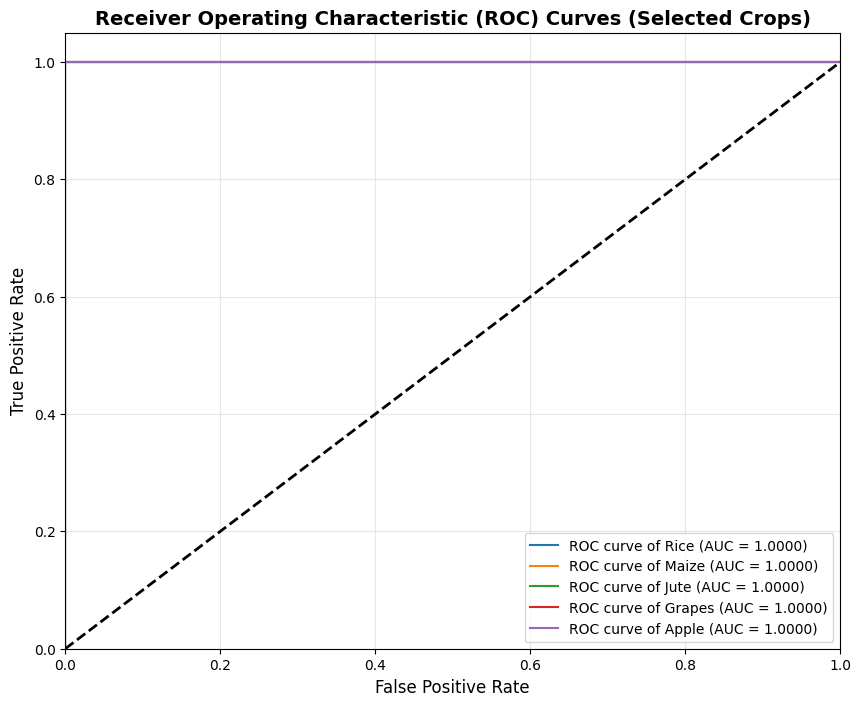

In [ ]:
# Identify best model based on F1-Score
best_model_name = results_df.sort_values(by='F1-Score', ascending=False).iloc[0]['Model']
best_model = models[best_model_name]
print(f"Best Model Selected: {best_model_name}")

# Predictions for Best Model
ypred_best = best_model.predict(X_test)
cm = confusion_matrix(y_test, ypred_best)

# Plot Confusion Matrix
crop_names = [crop_names_dict[i] for i in sorted(crop_names_dict.keys())]
plt.figure(figsize=(14, 12))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', xticklabels=crop_names, yticklabels=crop_names)
plt.title(f"Confusion Matrix - {best_model_name} (Research Paper Figure)", fontsize=14, fontweight='bold')
plt.xlabel("Predicted Label", fontsize=12)
plt.ylabel("True Label", fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig("combined_confusion_matrix.png", dpi=300)
plt.show()

# Multiclass ROC Curves for selected representative crops
from sklearn.preprocessing import label_binarize
y_test_bin = label_binarize(y_test, classes=list(crop_names_dict.keys()))
n_classes = y_test_bin.shape[1]
y_score = best_model.predict_proba(X_test)

fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot ROC curves for illustrative crops (Rice, Maize, Jute, Grapes, Apple)
selected_classes = [0, 1, 2, 10, 7]
plt.figure(figsize=(10, 8))
for i in selected_classes:
    class_name = crop_names_dict[i]
    plt.plot(fpr[i], tpr[i], label=f'ROC curve of {class_name} (AUC = {roc_auc[i]:.4f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('Receiver Operating Characteristic (ROC) Curves (Selected Crops)', fontsize=14, fontweight='bold')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.savefig("combined_roc_curves.png", dpi=300)
plt.show()

## 8. Save the Best Performing Model and Scaler

In [9]:
# Save best model and scaler object for serialization
pickle.dump(best_model, open('best_crop_model.pkl', 'wb'))
pickle.dump(ms, open('best_crop_scaler.pkl', 'wb'))
print(f"Successfully saved {best_model_name} as 'best_crop_model.pkl'")
print("Successfully saved scaler as 'best_crop_scaler.pkl'")

Successfully saved Random Forest as 'best_crop_model.pkl'
Successfully saved scaler as 'best_crop_scaler.pkl'


## 9. Explainable AI: SHAP (SHapley Additive exPlanations)

SHAP computes Shapley values from game theory to show global feature impacts across the entire dataset and local impacts on specific predictions.

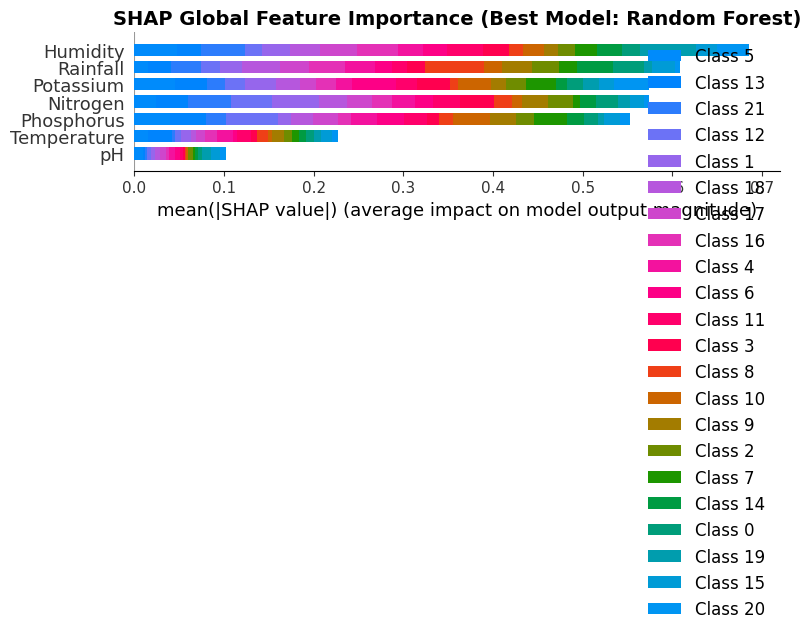

Explaining local prediction for sample 0 (Predicted Crop: Mungbean)


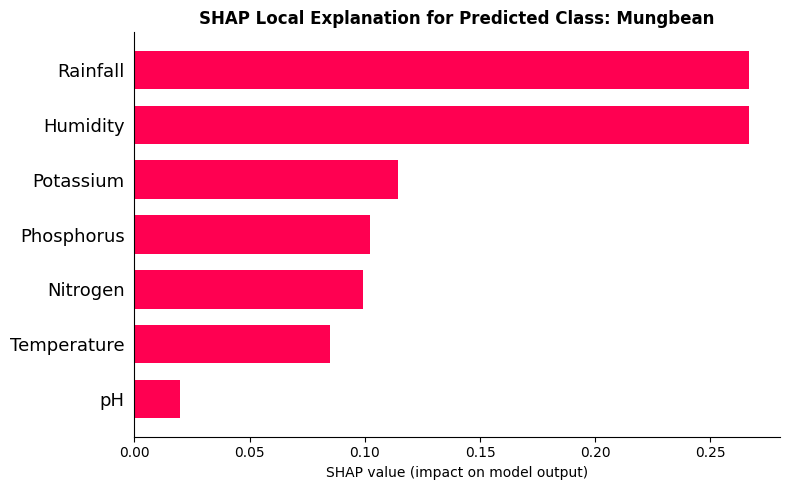

In [10]:
explainer = shap.TreeExplainer(best_model)

# Calculate SHAP values on first 100 samples of the test set
shap_values = explainer.shap_values(X_test[:100])
feature_list = ['Nitrogen', 'Phosphorus', 'Potassium', 'Temperature', 'Humidity', 'pH', 'Rainfall']

# Global Feature Importance Plot
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test[:100], feature_names=feature_list, plot_type="bar", show=False)
plt.title(f"SHAP Global Feature Importance (Best Model: {best_model_name})", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("combined_shap_global_importance.png", dpi=300)
plt.show()

# Local Feature Explanation for the first test instance
test_idx = 0
sample = X_test[test_idx:test_idx+1]
predicted_class_id = best_model.predict(sample)[0]
predicted_crop = crop_names_dict[predicted_class_id]
class_idx = list(best_model.classes_).index(predicted_class_id)

print(f"Explaining local prediction for sample {test_idx} (Predicted Crop: {predicted_crop})")

plt.figure(figsize=(8, 5))
if isinstance(shap_values, list):
    local_shap = shap_values[class_idx][test_idx]
else:
    local_shap = shap_values[test_idx, :, class_idx]

shap.bar_plot(local_shap, feature_names=feature_list, show=False)
plt.title(f"SHAP Local Explanation for Predicted Class: {predicted_crop}", fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig("combined_shap_local_explanation.png", dpi=300)
plt.show()

## 10. Explainable AI: LIME (Local Interpretable Model-agnostic Explanations)

LIME generates locally perturbed data to explain predictions on the original raw scale of features rather than scaled bounds, enhancing interpretability.

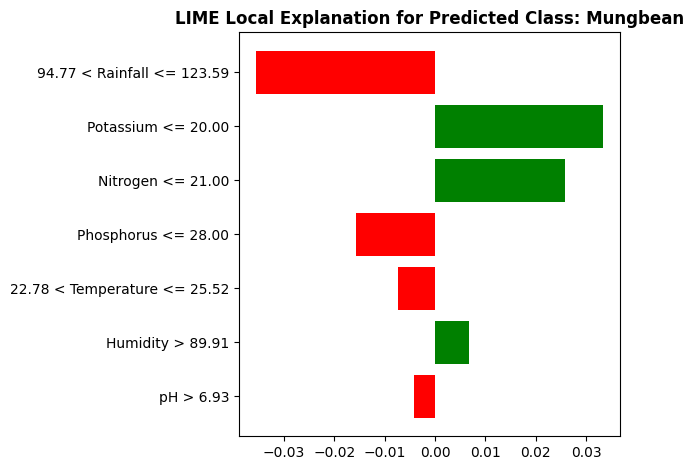

In [11]:
# Reload raw features to initialize LIME in original scales
df_raw = pd.read_csv('data 2/Crop Recommendation dataset.csv')
X_raw = df_raw.iloc[:, :-1].values
y_raw = df_raw.iloc[:, -1].values

X_train_raw, X_test_raw, y_train_raw, y_test_raw = train_test_split(X_raw, y_raw, test_size=0.2, random_state=42, stratify=y_raw)

# Predict function wrapper to scale inputs before passing to classifier
def predict_fn(x_raw):
    if len(x_raw.shape) == 1:
        x_raw = x_raw.reshape(1, -1)
    scaled = ms.transform(x_raw)
    return best_model.predict_proba(scaled)

# Initialize LIME Tabular Explainer
lime_explainer = lime_tabular.LimeTabularExplainer(
    training_data=X_train_raw,
    feature_names=feature_list,
    class_names=crop_names,
    mode='classification'
)

# Explain prediction on instance `test_idx`
exp = lime_explainer.explain_instance(
    data_row=X_test_raw[test_idx],
    predict_fn=predict_fn,
    num_features=7,
    labels=[class_idx]
)

# Plot and save LIME explanation
fig = exp.as_pyplot_figure(label=class_idx)
plt.title(f"LIME Local Explanation for Predicted Class: {predicted_crop}", fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig("combined_lime_local_explanation.png", dpi=300)
plt.show()

## 11. Intelligent Top-3 Crop Recommendation Engine

In [12]:
def recommend_top_3_crops(N, P, K, temp, humidity, pH, rainfall):
    features = np.array([[N, P, K, temp, humidity, pH, rainfall]])
    scaled_features = ms.transform(features)
    
    # Get probabilities from our best selected model
    probs = best_model.predict_proba(scaled_features)[0]
    top_3_indices = np.argsort(probs)[-3:][::-1]
    
    print(f"\n--- Top 3 Crop Recommendations ({best_model_name}) ---")
    results = []
    for rank, idx in enumerate(top_3_indices, 1):
        class_id = best_model.classes_[idx]
        prob = probs[idx]
        crop_name = crop_names_dict.get(class_id, "Unknown")
        results.append((crop_name, prob))
        print(f"Rank {rank}: {crop_name} ({prob*100:.2f}% match confidence)")
    return results

# Example Test Run (using Rice-like soil conditions)
print("Testing recommendation for: N=90, P=40, K=40, Temp=20.0, Humidity=80.0, pH=6.5, Rainfall=200.0")
recommend_top_3_crops(90, 40, 40, 20.0, 80.0, 6.5, 200.0)

Testing recommendation for: N=90, P=40, K=40, Temp=20.0, Humidity=80.0, pH=6.5, Rainfall=200.0

--- Top 3 Crop Recommendations (Random Forest) ---
Rank 1: Rice (87.00% match confidence)
Rank 2: Jute (12.00% match confidence)
Rank 3: Maize (1.00% match confidence)


[('Rice', 0.87), ('Jute', 0.12), ('Maize', 0.01)]